In [1]:
import pandas as pd
print("Setup Working Successfully!")

Setup Working Successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...


True

In [4]:
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

print(fake.shape)
print(true.shape)

(23481, 4)
(21417, 4)


In [5]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
fake["label"] = 0
true["label"] = 1

In [8]:
data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1).reset_index(drop=True)

data.head()

,title,text,subject,date,label
0,DEADBEATS BEWARE: Trump’s Food Stamp Reform Is...,All we re hearing from the left is fear monger...,left-news,"May 26, 2017",0
1,"GOVERNMENT GONE WILD: Sell A Cookie, Go To Jai...",Wisconsin is losing me on this one-no common s...,Government News,"Jan 19, 2016",0
2,Trump and Japan's Abe agree to keep pressure o...,TOKYO (Reuters) - U.S. President Donald Trump ...,worldnews,"October 4, 2017",1
3,Flint’s Mayor Knows Which Candidate Has Their...,Governor Rick Snyder and his emergency managem...,News,"January 19, 2016",0
4,"Sarah Palin’s Idiocy Strikes Again, Urges Us ...",In what some may assume is a misspeak and othe...,News,"April 5, 2016",0


In [9]:
print("Dataset Size:", data.shape)

Dataset Size: (44898, 5)


In [10]:
data = data[["text", "label"]]

In [11]:
data.head()

,text,label
0,All we re hearing from the left is fear monger...,0
1,Wisconsin is losing me on this one-no common s...,0
2,TOKYO (Reuters) - U.S. President Donald Trump ...,1
3,Governor Rick Snyder and his emergency managem...,0
4,In what some may assume is a misspeak and othe...,0


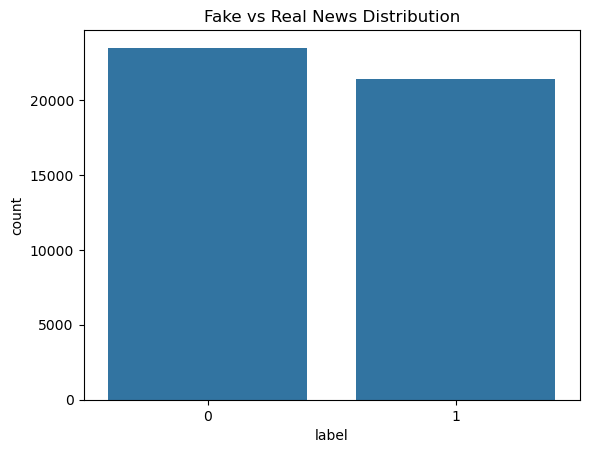

In [12]:
sns.countplot(x=data["label"])
plt.title("Fake vs Real News Distribution")
plt.show()

In [13]:
data.isnull().sum()

text     0
label    0
dtype: int64

In [14]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [15]:
data["text"] = data["text"].apply(clean_text)

In [16]:
data.head()

,text,label
0,hearing left fear mongering president trump bu...,0
1,wisconsin losing oneno common sense whatsoever...,0
2,tokyo reuters u president donald trump japanes...,1
3,governor rick snyder emergency management team...,0
4,may assume misspeak others may attribute freud...,0


In [17]:
data.to_csv("../data/clean_news.csv", index=False)

In [18]:
import pandas as pd

data = pd.read_csv("../data/clean_news.csv")

data.head()

,text,label
0,hearing left fear mongering president trump bu...,0
1,wisconsin losing oneno common sense whatsoever...,0
2,tokyo reuters u president donald trump japanes...,1
3,governor rick snyder emergency management team...,0
4,may assume misspeak others may attribute freud...,0


In [19]:
print(data.shape)

(44898, 2)


In [20]:
X = data["text"]
y = data["label"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (35918,)
Testing size: (8980,)


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [26]:
data.isnull().sum()

text     716
label      0
dtype: int64

In [27]:
data = data.dropna()

In [28]:
data["text"] = data["text"].astype(str)

In [29]:
X = data["text"]
y = data["label"]

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [33]:
data = data[data["text"].str.strip() != ""]

In [34]:
print(type(X_train.iloc[0]))

<class 'str'>


In [35]:
print(X_train_vec.shape)

(35345, 5000)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_vec, y_train)

pred_lr = lr.predict(X_test_vec)

accuracy_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9903813511372638


In [37]:
from sklearn.linear_model import PassiveAggressiveClassifier

pac = PassiveAggressiveClassifier(max_iter=1000)

pac.fit(X_train_vec, y_train)

pred_pac = pac.predict(X_test_vec)

accuracy_pac = accuracy_score(y_test, pred_pac)

print("Passive Aggressive Accuracy:", accuracy_pac)

Passive Aggressive Accuracy: 0.9964920221794726


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train_vec, y_train)

pred_rf = rf.predict(X_test_vec)

accuracy_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.998755233676587


In [39]:
print("Logistic Regression:", accuracy_lr)
print("Passive Aggressive:", accuracy_pac)
print("Random Forest:", accuracy_rf)

Logistic Regression: 0.9903813511372638
Passive Aggressive: 0.9964920221794726
Random Forest: 0.998755233676587


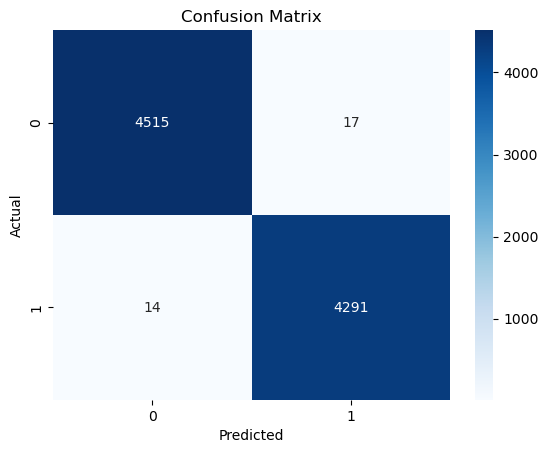

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_pac)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
import pickle

pickle.dump(pac, open("../models/model.pkl", "wb"))
pickle.dump(vectorizer, open("../models/vectorizer.pkl", "wb"))

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4532
           1       1.00      1.00      1.00      4305

    accuracy                           1.00      8837
   macro avg       1.00      1.00      1.00      8837
weighted avg       1.00      1.00      1.00      8837



In [43]:
proba = rf.predict_proba(X_test_vec)

print(proba[:5])

[[0.63 0.37]
 [0.97 0.03]
 [0.16 0.84]
 [0.03 0.97]
 [0.15 0.85]]


In [55]:
def predict_news(news):

    news = news.lower().strip()

    news_vec = vectorizer.transform([news])

    prediction = rf.predict(news_vec)[0]

    probs = rf.predict_proba(news_vec)[0]

    real_prob = probs[0] * 100
    fake_prob = probs[1] * 100

    if prediction == 0:
        label = "REAL NEWS"
    else:
        label = "FAKE NEWS"

    print("Prediction:", label)
    print("Real Probability:", round(real_prob,2), "%")
    print("Fake Probability:", round(fake_prob,2), "%")

In [56]:
print(data["label"].value_counts())

label
0    22766
1    21416
Name: count, dtype: int64


In [57]:
predict_news("Aliens landed in New York and took control of the US government")

Prediction: REAL NEWS
Real Probability: 69.0 %
Fake Probability: 31.0 %


In [58]:
import pickle

pickle.dump(rf, open("../models/fake_news_model.pkl", "wb"))
pickle.dump(vectorizer, open("../models/vectorizer.pkl", "wb"))